In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import cv2
import sklearn
import PIL
import torch
import torchvision
from matplotlib import cm

import warnings
warnings.filterwarnings('ignore')

### Зачем
- Посмотрим, как проводится операция свертки;
- Посмотрим, как работает pooling;
- Попробуем собрать сверточную нейронную сеть на PyTorch

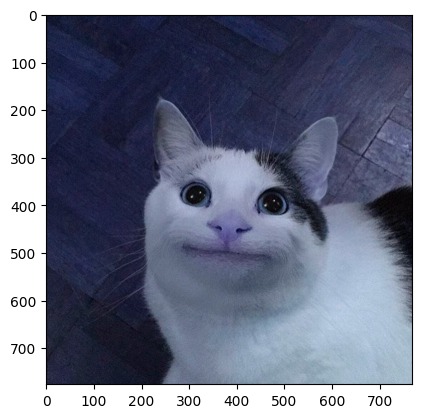

In [13]:
image = cv2.imread('./image.png')
plt.imshow(image);

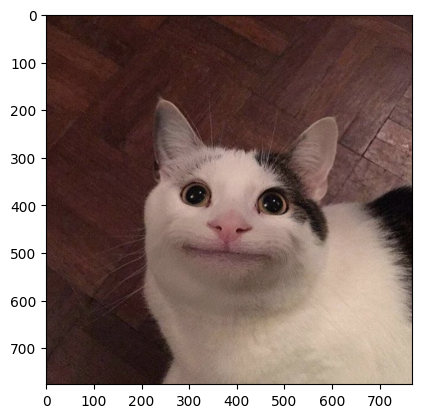

In [3]:
image_ex = image[...,::-1]
plt.imshow(image_ex)

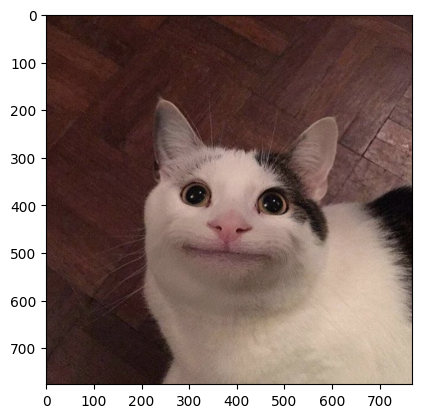

In [4]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb);

Посмотрим на каналы изображения отдельно

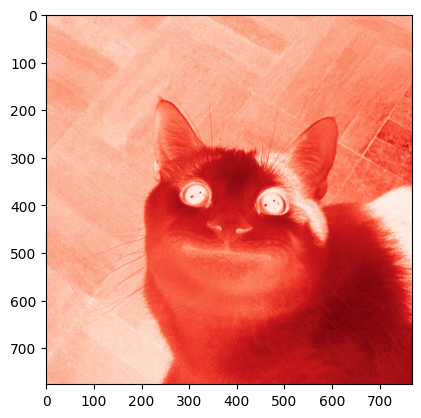

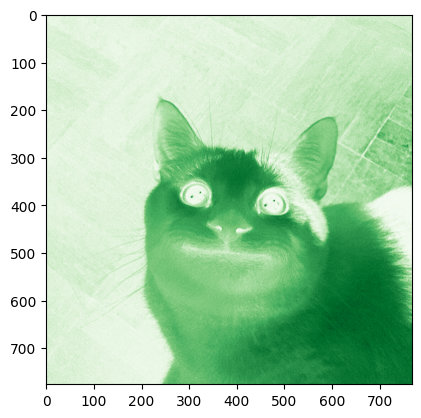

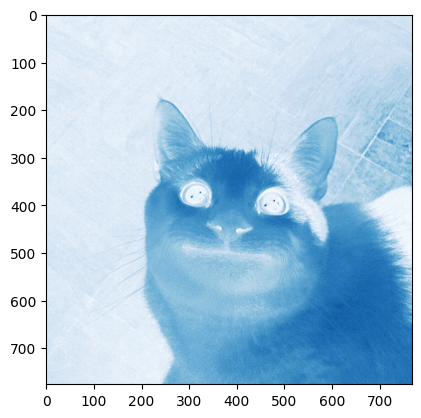

In [5]:
img_mat = np.array(image_rgb)
plt.imshow(img_mat[:, :, 0], cmap=cm.Reds)
plt.show()

img_mat = np.array(image_rgb)
plt.imshow(img_mat[:, :, 1], cmap=cm.Greens)
plt.show()

img_mat = np.array(image_rgb)
plt.imshow(img_mat[:, :, 2], cmap=cm.Blues)
plt.show()

# Операция свертки

- Количество входных каналов `in_channels`
- Количество выходных каналов `out_channels`
- Размер ядра `kernel_size`
- Шаг `stride`
- Паддинг `padding`
- Режим паддинга `padding_mode` (`'zeros'`, `'reflect'`, ...)


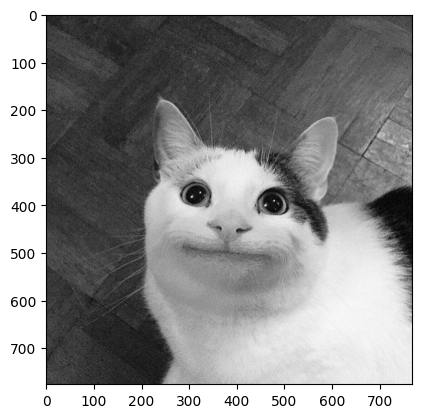

In [6]:
bw_image = cv2.imread('./image.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(bw_image, cmap=plt.cm.Greys_r)

In [7]:
# !pip3 install scipy

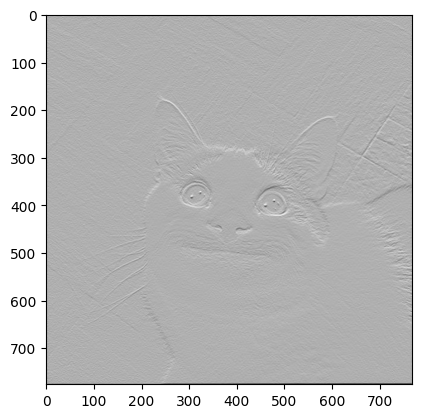

In [7]:
from scipy.signal import convolve2d

G_y = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
])

res_y = convolve2d(bw_image, G_y, "same")
plt.imshow(res_y, cmap=plt.cm.Greys_r)

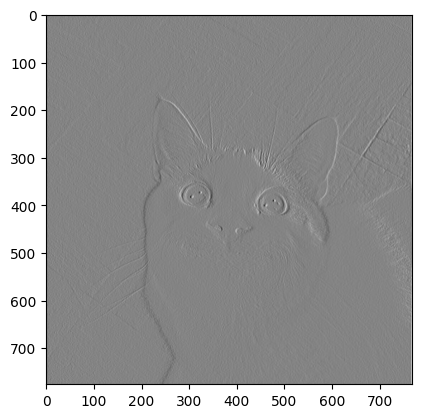

In [9]:
G_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

res_x = convolve2d(bw_image, G_x, "same")
plt.imshow(res_x, cmap=plt.cm.Greys_r)

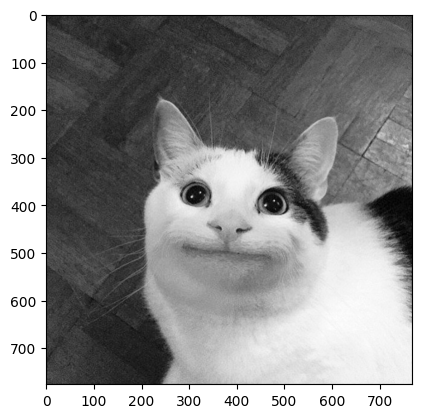

In [13]:
G_x = np.array([
    [0, 1, 0],
    [1, 6, 1],
    [0, 1, 0]
])

res_x = convolve2d(bw_image, G_x, "same")
plt.imshow(res_x, cmap=plt.cm.Greys_r)

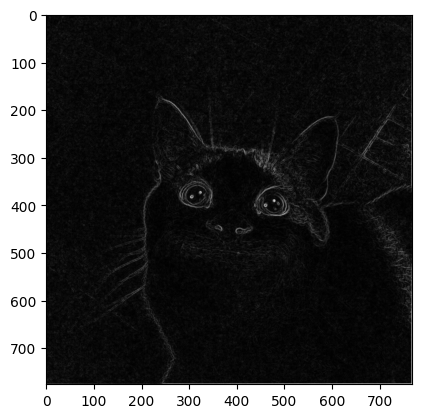

In [10]:
res_sobel = (res_x**2 + res_y**2)**0.5
plt.imshow(res_sobel, cmap=plt.cm.Greys_r)

# Пулинг

In [14]:
import numpy as np

conv_output = np.array([
    [10, 12,  8,  7],
    [ 4, 11,  5,  9],
    [18, 13,  7,  7],
    [ 3, 15,  2,  2]
])
conv_output

array([[10, 12,  8,  7],
       [ 4, 11,  5,  9],
       [18, 13,  7,  7],
       [ 3, 15,  2,  2]])

Сначала попробуем со `stride=2`

In [15]:
pool_size = 2
stride = 2

def get_pools(img=conv_output, pool_size=2, stride=2):

    pools = []
    for i in np.arange(conv_output.shape[0], step=stride):
        for j in np.arange(conv_output.shape[0], step=stride):
            mat = conv_output[i:i+pool_size, j:j+pool_size]
            pools.append(mat)
    pools = np.array(pools)
    return pools

pools = get_pools()
pools

array([[[10, 12],
        [ 4, 11]],

       [[ 8,  7],
        [ 5,  9]],

       [[18, 13],
        [ 3, 15]],

       [[ 7,  7],
        [ 2,  2]]])

In [16]:
def max_pooling(pools: np.array) -> np.array:

    num_pools = pools.shape[0]

    # Размер матрицы после пулинга
    tgt_shape = (int(np.sqrt(num_pools)), int(np.sqrt(num_pools)))

    # Здесь будем хранить максимумы с каждого из пулов
    pooled = []
    for pool in pools:
        pooled.append(np.max(pool))

    return np.array(pooled).reshape(tgt_shape)

In [17]:
max_pooling(pools=pools)

array([[12,  9],
       [18,  7]])

# Сверточная нейронная сеть

In [2]:
import torch
import torch.nn.functional as F
import torchvision
import os
from torch import nn
from tqdm import tqdm

In [23]:
transform = torchvision.transforms.Compose(
    [
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize((0.1307,), (0.3081,))
    ]
)

In [ ]:
def seed_everything(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


In [24]:
seed_everything(1234)

mnist_train = torchvision.datasets.MNIST(
    './mnist/',
    train=True,
    download=True,
    transform=transform
)

mnist_val = torchvision.datasets.MNIST(
    './mnist/',
    train=False,
    download=True,
    transform=transform
)

train_dataloader = torch.utils.data.DataLoader(mnist_train, batch_size=64, shuffle=True)
val_dataloader = torch.utils.data.DataLoader(mnist_val, batch_size=64, shuffle=True)

In [41]:
plt.imshow(mnist_train[0][0].squeeze(0).numpy().reshape([28, 28]))

NameError: name 'mnist_train' is not defined

In [12]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [30]:
def train(model, optimizer, n_epochs=5):

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    for epoch in range(n_epochs):
        
        # обучение
        for x_train, y_train in tqdm(train_dataloader):
            x_train, y_train = x_train.to(device), y_train.to(device)
            y_pred = model(x_train)
            loss = F.cross_entropy(y_pred, y_train)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        # валидация
        if epoch % 2 == 0:
            val_loss = []
            val_accuracy = []
            with torch.no_grad():
                for x_val, y_val in tqdm(val_dataloader):
                    x_val, y_val = x_val.to(device), y_val.to(device)
                    y_pred = model(x_val)
                    loss = F.cross_entropy(y_pred, y_val)
                    val_loss.append(loss.item())
                    preds = y_pred.argmax(dim=-1)
                    correct = (preds == y_val).cpu().numpy()
                    val_accuracy.extend(correct.tolist())

            print(f'Epoch: {epoch}, loss: {np.mean(val_loss)}, accuracy: {np.mean(val_accuracy)}')

In [31]:
train(model, optimizer)

100%|██████████| 157/157 [00:03<00:00, 41.09it/s]


Epoch: 0, loss: 0.13592728784984084, accuracy: 0.9608


100%|██████████| 157/157 [00:03<00:00, 48.22it/s]


Epoch: 2, loss: 0.09508782427663066, accuracy: 0.9714


100%|██████████| 157/157 [00:03<00:00, 47.37it/s]

Epoch: 4, loss: 0.07317370729176861, accuracy: 0.976


In [23]:
0.9462

0.9462

In [32]:
model = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=10, kernel_size=5),  # grayscale
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=4),   # сократим изображение в 4 раза по каждой из сторон
    nn.Flatten(),
    nn.Linear(6*6*10, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [33]:
train(model, optimizer)

100%|██████████| 157/157 [00:03<00:00, 44.80it/s]


Epoch: 0, loss: 0.21791496872901917, accuracy: 0.9388


100%|██████████| 157/157 [00:03<00:00, 45.81it/s]


Epoch: 2, loss: 0.10968803602513993, accuracy: 0.9676


100%|██████████| 157/157 [00:03<00:00, 45.38it/s]

Epoch: 4, loss: 0.07790412886103817, accuracy: 0.977


In [27]:
0.9747

0.9747

# Домашнее задание

Обучите сверточную нейронную сеть на датасете MNIST, взяв любой другой оптимизатор (кроме SGD) и любую другую функцию ошибки (кроме cross-entropy loss). Попробуйте поварьировать параметры: кол-во ядер, `kernel_size` и побить текущий бейзлайн в `0.977
`. Выведите количество обучаемых параметров.    
Какого качества удалось достичь? Попробуйте залоггировать Ваши результаты - построить графики того, как менялись метрики качества (accuracy, loss) с течением эпох, включить логгирование, сравнить результаты между собой при разных параметрах.

Любые дополнительные улучшения (как по методам, так и по коду пайплайна) приветствуются!

*Цель:* выработать навык обучения нейронных сетей (в частности сверточных) на основе средств PyTorch, начиная от загрузки датасетами и заканчивая выводами результатов, их логгированием, сравнением и анализом.

In [3]:
import random

def seed_everything(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

seed_everything(1234)

In [5]:
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
seed_everything(1234)
train_transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])


train_ds = datasets.MNIST('.', train=True, download=True, transform=train_transform)
val_ds = datasets.MNIST('.', train=False, transform=val_transform)

trainloader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2)
valloader = DataLoader(val_ds, batch_size=1000, shuffle=True, num_workers=2)


In [ ]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

optimizer = AdamW(params=model.parameters(), lr=1e-3, weight_decay=1e-4)

criterion = nn.MultiMarginLoss(margin=1.0, p=1)  

In [35]:
def train(model ,optimizer, criterion, trainloader, valloader, max_lr=1e-2, plot=True, device='cuda', n_epochs=10):  #min_delta=1e-4, early_stopping=True, patience=2
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    best_loss  = np.inf
    counter    = 0
    best_state = None
    model.to(device)
    model.train()
    scheduler = OneCycleLR(
        optimizer,
        max_lr=max_lr,
        steps_per_epoch=len(trainloader),
        epochs=n_epochs,
        anneal_strategy='cos'
    )
    for epoch in range(n_epochs):
        total_loss, total_samples, correct = 0.0, 0, 0
        for x_train, y_train in tqdm(trainloader):
            x_train, y_train = x_train.to(device), y_train.to(device)
            optimizer.zero_grad()
            y_pred = model(x_train)
            loss = criterion(y_pred, y_train)
            loss.backward()
            optimizer.step()
            scheduler.step()
            total_loss += loss.item() * x_train.size(0)
            total_samples += x_train.size(0)
            correct += (y_pred.argmax(dim=1) == y_train).sum().item()
        avg_train_loss = total_loss / total_samples
        train_losses.append(avg_train_loss)
        train_acc = correct / total_samples
        train_accuracies.append(train_acc)
        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for x_val, y_val in tqdm(valloader):
                x_val, y_val = x_val.to(device), y_val.to(device)
                y_pred = model(x_val)
                loss = criterion(y_pred, y_val)
                val_loss += loss.item() * x_val.size(0)
                correct += (y_pred.argmax(dim=1) == y_val).sum().item()
                total += y_val.size(0)
            avg_val_loss = val_loss / total
            val_acc = correct / total
            val_losses.append(avg_val_loss)
            val_accuracies.append(val_acc)
            print(
            f'Epoch {epoch:02d} | '
            f'Train Loss: {avg_train_loss:.4f} | '
            f'Val Loss: {avg_val_loss:.4f} | '
            f'Train Acc: {train_acc:.4f} | '
            f'Val acc: {val_acc:.4f}'
            ) 

            #Early Stopping
            # if early_stopping:
            #     if avg_val_loss + min_delta < best_loss:
            #         best_loss  = avg_val_loss
            #         counter    = 0
            #         best_state = model.state_dict()
            #     else:
            #         counter += 1
            #         if counter >= patience:
            #             print(f"EarlyStopping: остановка на эпохе {epoch}. "
            #                 f"Лучший val_loss = {best_loss:.4f}")
            #             break

    if plot:
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 3, 1)
        plt.plot(train_losses, label='Train Loss')
        plt.plot(val_losses, label='Val Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Loss over Epochs')
        plt.legend()

        plt.subplot(1, 3, 2)
        plt.plot(val_accuracies, label='Val Accuracy', color='green')
        plt.plot(train_accuracies, label='Train Accuracy', color='orange')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.title('Validation Accuracy')
        plt.legend()

        plt.tight_layout()
        plt.show()

    return train_losses, \
            val_losses, \
            val_accuracies,\
            train_accuracies
            
    

100%|██████████| 10/10 [00:05<00:00,  1.68it/s]


Epoch 00 | Train Loss: 0.0400 | Val Loss: 0.0113 | Train Acc: 0.9256 | Val acc: 0.9657


100%|██████████| 10/10 [00:05<00:00,  1.68it/s]


Epoch 01 | Train Loss: 0.0097 | Val Loss: 0.0040 | Train Acc: 0.9746 | Val acc: 0.9884


100%|██████████| 10/10 [00:05<00:00,  1.69it/s]


...

100%|██████████| 10/10 [00:06<00:00,  1.49it/s]


Epoch 01 | Train Loss: 0.8850 | Val Loss: 0.8829 | Train Acc: 0.1089 | Val acc: 0.1135


100%|██████████| 10/10 [00:06<00:00,  1.50it/s]

Epoch 02 | Train Loss: 0.8817 | Val Loss: 0.8830 | Train Acc: 0.1105 | Val acc: 0.1135
7 [64, 128, 256]


<function matplotlib.pyplot.show(close=None, block=None)>

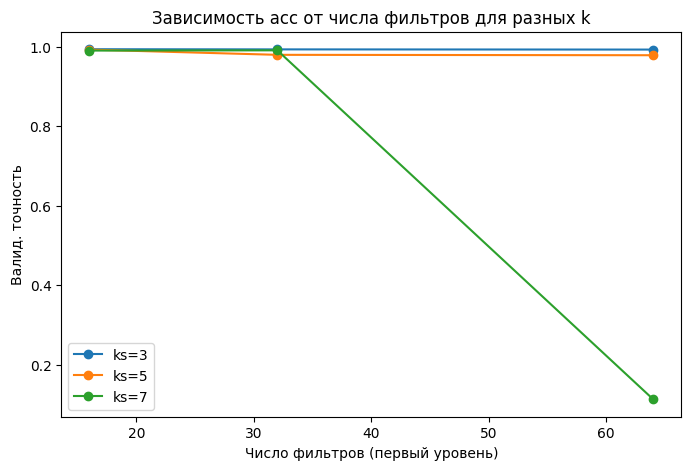

In [13]:
import itertools
import pandas as pd

def make_model(kernel_size, channels):
    class Net(nn.Module):
        def __init__(self):
            super().__init__()
            ch1, ch2, ch3 = channels
            pad = kernel_size // 2
            self.conv1 = nn.Conv2d(1,    ch1, kernel_size, padding=pad)
            self.conv2 = nn.Conv2d(ch1,  ch2, kernel_size, padding=pad)
            self.conv3 = nn.Conv2d(ch2,  ch3, kernel_size, padding=pad)
            self.pool  = nn.MaxPool2d(2, 2)
            self.fc1   = nn.Linear(ch3 * 7 * 7, 256)
            self.fc2   = nn.Linear(256, 10)
        def forward(self, x):
            x = F.relu(self.conv1(x))
            x = self.pool(F.relu(self.conv2(x)))
            x = self.pool(F.relu(self.conv3(x)))
            x = x.view(x.size(0), -1)
            x = F.relu(self.fc1(x))
            return self.fc2(x)
    return Net()

kernel_sizes = [3, 5, 7]
filter_options = [ [16,32,64], [32,64,128], [64,128,256] ]

results = []

for ksz, chans in itertools.product(kernel_sizes, filter_options):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = make_model(ksz, chans).to(device)
    optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    train_losses, val_losses, val_accs, train_accs = train(
        model, optimizer, criterion,
        trainloader, valloader,
        max_lr=1e-2, plot=False,
        device=device, n_epochs=3
    )
    print(ksz, chans)
    results.append({
        'kernel_size': ksz,
        'filters': chans[0],
        'val_acc': val_accs[-1]
    })
df = pd.DataFrame(results)

plt.figure(figsize=(8,5))
for ksz in kernel_sizes:
    sub = df[df['kernel_size']==ksz]
    plt.plot(sub['filters'], sub['val_acc'], marker='o', label=f'ks={ksz}')
plt.xlabel('Число фильтров (первый уровень)')
plt.ylabel('Валид. точность')
plt.title('Зависимость acc от числа фильтров для разных k')
plt.legend()
plt.show

In [14]:
df

,kernel_size,filters,val_acc
0,3,16,0.9932
1,3,32,0.9928
2,3,64,0.9923
3,5,16,0.9922
4,5,32,0.9791
5,5,64,0.9781
6,7,16,0.9898
7,7,32,0.9904
8,7,64,0.1135


Лучшее: kernel_size: 3, fiters: [16,32,64]

  0%|          | 0/938 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:06<00:00,  1.67it/s]


Epoch 00 | Train Loss: 0.0421 | Val Loss: 0.0125 | Train Acc: 0.9244 | Val acc: 0.9650


100%|██████████| 10/10 [00:05<00:00,  1.67it/s]


Epoch 01 | Train Loss: 0.0144 | Val Loss: 0.0076 | Train Acc: 0.9647 | Val acc: 0.9796


...

Epoch 02 | Train Loss: 0.0070 | Val Loss: 0.0079 | Train Acc: 0.9841 | Val acc: 0.9839


100%|██████████| 10/10 [00:05<00:00,  1.68it/s]


Epoch 03 | Train Loss: 0.0039 | Val Loss: 0.0042 | Train Acc: 0.9891 | Val acc: 0.9889


100%|██████████| 10/10 [00:05<00:00,  1.72it/s]


Epoch 04 | Train Loss: 0.0022 | Val Loss: 0.0038 | Train Acc: 0.9934 | Val acc: 0.9909


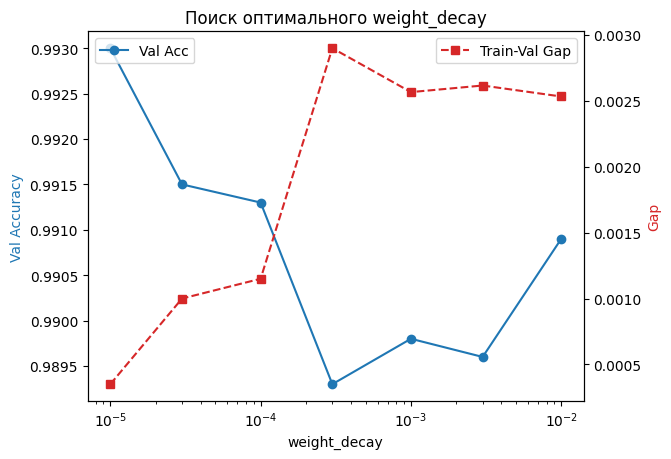

In [18]:
wd_list = [1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2]
results = []
model = make_model(3, [16,32,64]).to(device)
for wd in wd_list:
    optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=wd)
    _, _, val_accs, train_accs = train(
        model, optimizer, criterion,
        trainloader, valloader,
        max_lr=1e-2, n_epochs=5, plot=False, device=device
    )
    results.append({
        'wd': wd,
        'val_acc': val_accs[-1],
        'gap': train_accs[-1] - val_accs[-1]
    })

wd_vals = [r['wd'] for r in results]
val_accs = [r['val_acc'] for r in results]
gaps     = [r['gap']     for r in results]

fig, ax1 = plt.subplots()
ax1.semilogx(wd_vals, val_accs, 'o-', label='Val Acc')
ax1.set_xlabel('weight_decay')
ax1.set_ylabel('Val Accuracy', color='tab:blue')
ax2 = ax1.twinx()
ax2.semilogx(wd_vals, gaps, 's--', color='tab:red', label='Train-Val Gap')
ax2.set_ylabel('Gap', color='tab:red')
ax1.legend(loc='upper left'); ax2.legend(loc='upper right')
plt.title('Поиск оптимального weight_decay')
plt.show()

Самый оптимальный weight_decay 1e-5

100%|██████████| 10/10 [00:06<00:00,  1.63it/s]


Epoch 00 | Train Loss: 0.0108 | Val Loss: 0.0143 | Train Acc: 0.9805 | Val acc: 0.9713


100%|██████████| 10/10 [00:06<00:00,  1.49it/s]


Epoch 01 | Train Loss: 0.0240 | Val Loss: 0.0205 | Train Acc: 0.9687 | Val acc: 0.9754


100%|██████████| 10/10 [00:06<00:00,  1.65it/s]


...

Epoch 02 | Train Loss: 0.0096 | Val Loss: 0.0127 | Train Acc: 0.9862 | Val acc: 0.9831


100%|██████████| 10/10 [00:05<00:00,  1.67it/s]


Epoch 03 | Train Loss: 0.0061 | Val Loss: 0.0119 | Train Acc: 0.9894 | Val acc: 0.9862


100%|██████████| 10/10 [00:05<00:00,  1.67it/s]


Epoch 04 | Train Loss: 0.0041 | Val Loss: 0.0117 | Train Acc: 0.9916 | Val acc: 0.9876


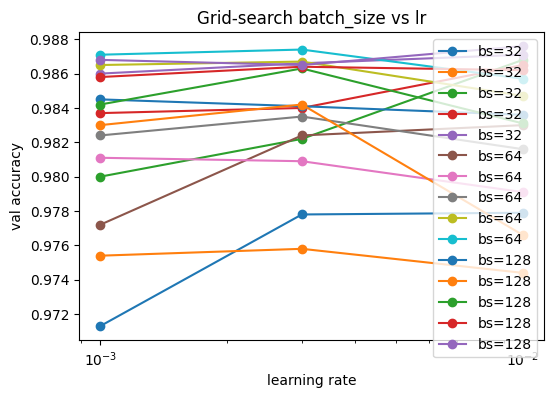

In [37]:
batch_sizes = [32, 64, 128]
lrs = [1e-3, 3e-3, 1e-2]
results = []

for bs, lr in itertools.product(batch_sizes, lrs):
    trainloader = DataLoader(train_ds, batch_size=bs, shuffle=True, num_workers=2)
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    _, _, val_accs, _ = train(
        model, optimizer, criterion,
        trainloader, valloader,
        max_lr=1e-2, n_epochs=5, plot=False, device=device)
    results.append({'batch_size': bs, 'lr': lr, 'val_acc': val_accs})

df = results
plt.figure(figsize=(6,4))
for bs in batch_sizes:
    subset = [r for r in df if r['batch_size']==bs]
    lrs_plot = [r['lr'] for r in subset]
    accs = [r['val_acc'] for r in subset]
    plt.plot(lrs_plot, accs, marker='o', label=f'bs={bs}')
plt.xscale('log')
plt.xlabel('learning rate')
plt.ylabel('val accuracy')
plt.legend()
plt.title('Grid-search batch_size vs lr')
plt.show()
    

batch_size: 64, lr: 1e-3

  0%|          | 0/938 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:05<00:00,  1.70it/s]


Epoch 00 | Train Loss: 0.0392 | Val Loss: 0.0102 | Train Acc: 0.9277 | Val acc: 0.9722


100%|██████████| 10/10 [00:05<00:00,  1.69it/s]


Epoch 01 | Train Loss: 0.0114 | Val Loss: 0.0098 | Train Acc: 0.9697 | Val acc: 0.9724


...

Epoch 07 | Train Loss: 0.0029 | Val Loss: 0.0042 | Train Acc: 0.9919 | Val acc: 0.9904


100%|██████████| 10/10 [00:05<00:00,  1.67it/s]


Epoch 08 | Train Loss: 0.0019 | Val Loss: 0.0033 | Train Acc: 0.9942 | Val acc: 0.9919


100%|██████████| 10/10 [00:06<00:00,  1.49it/s]


Epoch 09 | Train Loss: 0.0012 | Val Loss: 0.0032 | Train Acc: 0.9962 | Val acc: 0.9922


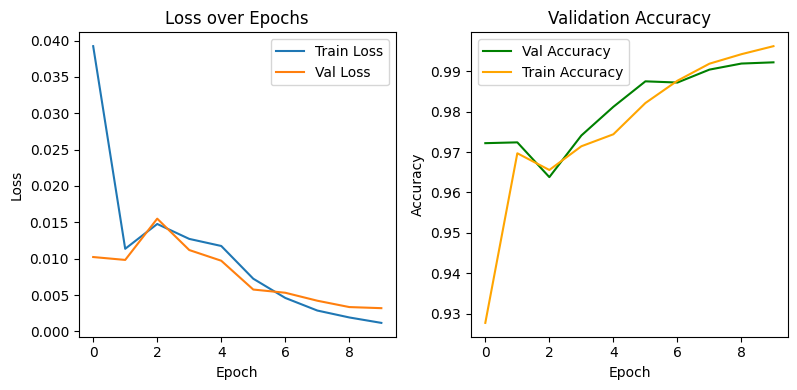

In [39]:
trainloader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2)

model = make_model(3, [16,32,64]).to(device)

optimizer = AdamW(params=model.parameters(), lr=1e-3, weight_decay=1e-5)

criterion = nn.MultiMarginLoss(margin=1.0, p=1)  
 
train_loss, vall_loss, vall_acc, train_acc = train(model, optimizer, criterion, trainloader, valloader, n_epochs=10, plot=True)

Val acc: 0.9922